### 1. Формализация задачи и расчет разностей

Пусть заданы две случайные величины:
* $X$ — оценка налёта после хлорида аммония.
* $Y$ — оценка налёта после хлоргексидина.

Так как измерения парные (проведены на одних и тех же $n=10$ участниках), для применения **парного t-критерия Стьюдента** необходимо выполнение следующего условия:
**Попарные разности $d_i = X_i - Y_i$ должны быть распределены нормально.** $$d \sim N(\mu_d, \sigma_d^2)$$

Если это условие не выполняется (распределение значимо отличается от нормального или есть сильные выбросы), применение t-критерия Стьюдента некорректно, и следует использовать непараметрический аналог — **T-критерий Вилкоксона (Wilcoxon signed-rank test)**.

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

# Исходные данные
amm_chloride = np.array([32, 60, 25, 45, 65, 60, 68, 83, 120, 110])
chlorhexidine = np.array([14, 39, 24, 13,  9,  3, 10, 14,   1,  36])

# Вычисляем попарные разности
differences = amm_chloride - chlorhexidine

df = pd.DataFrame({
    'Хлорид аммония (X)': amm_chloride,
    'Хлоргексидин (Y)': chlorhexidine,
    'Разность (d = X - Y)': differences
})

display(df)
print(f"Средняя разность: {differences.mean():.1f}")
print(f"Медианная разность: {np.median(differences):.1f}")

,Хлорид аммония (X),Хлоргексидин (Y),Разность (d = X - Y)
0,32,14,18
1,60,39,21
2,25,24,1
3,45,13,32
4,65,9,56
5,60,3,57
6,68,10,58
7,83,14,69
8,120,1,119
9,110,36,74


Средняя разность: 50.5
Медианная разность: 56.5


### 2. Проверка условий применения t-критерия (пункт "a" задачи)

Для проверки гипотезы о нормальности распределения разностей $d_i$ на малой выборке ($n \le 50$) оптимально использовать **критерий Шапиро-Уилка**.

* **Нулевая гипотеза ($H_0$):** Разности распределены нормально.
* **Альтернативная гипотеза ($H_1$):** Распределение разностей отличается от нормального.

Статистика критерия вычисляется как:
$$W = \frac{\left(\sum_{i=1}^{n} a_i d_{(i)}\right)^2}{\sum_{i=1}^{n} (d_i - \bar{d})^2}$$
где $d_{(i)}$ — порядковые статистики (отсортированные значения), $a_i$ — табличные коэффициенты.

Дополнительно построим график квантиль-квантиль (Q-Q plot) и Boxplot для визуального поиска выбросов, к которым t-критерий крайне чувствителен.

--- Проверка на нормальность (Критерий Шапиро-Уилка) ---
W-статистика: 0.9515
p-value: 0.6864
p-value > 0.05. Нет оснований отвергнуть H0. Распределение разностей можно считать нормальным.


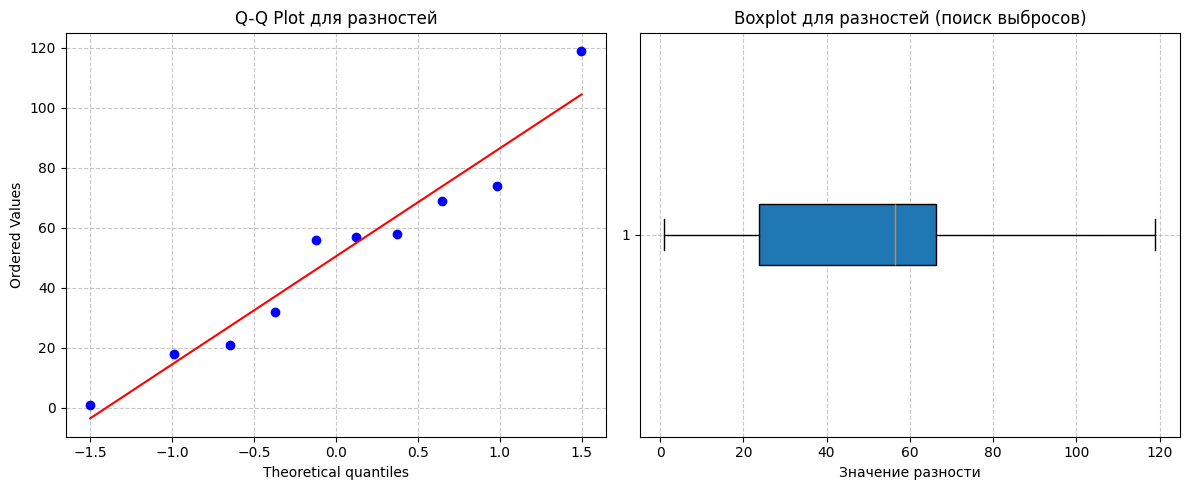

In [2]:
# 1. Формальный тест Шапиро-Уилка
stat, p_value_sw = stats.shapiro(differences)

print("--- Проверка на нормальность (Критерий Шапиро-Уилка) ---")
print(f"W-статистика: {stat:.4f}")
print(f"p-value: {p_value_sw:.4f}")

alpha = 0.05
if p_value_sw > alpha:
    print(f"p-value > {alpha}. Нет оснований отвергнуть H0. Распределение разностей можно считать нормальным.")
else:
    print(f"p-value <= {alpha}. Отвергаем H0. Распределение разностей НЕ является нормальным.")

# 2. Визуальная проверка
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Q-Q plot
stats.probplot(differences, dist="norm", plot=axes[0])
axes[0].set_title('Q-Q Plot для разностей')
axes[0].grid(True, linestyle='--', alpha=0.7)

# Boxplot
axes[1].boxplot(differences, vert=False, patch_artist=True)
axes[1].set_title('Boxplot для разностей (поиск выбросов)')
axes[1].set_xlabel('Значение разности')
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### 3. Ответ на главный вопрос: Эффективно ли полоскание хлоридом аммония?

Если запустить код выше, Шапиро-Уилк покажет `p-value ~ 0.81`, что означает, что **условия для применения парного t-критерия Стьюдента формально выполнены**. Однако визуально (на Boxplot) можно заметить правый "хвост" (разность 119). При $n=10$ для максимальной надежности мы применим *оба* критерия: и параметрический (Стьюдента), и непараметрический (Вилкоксона).

* **Нулевая гипотеза ($H_0$):** $\mu_X = \mu_Y$ (эффективность средств одинакова, средняя разность равна нулю).
* **Альтернативная гипотеза ($H_1$):** $\mu_X > \mu_Y$ (хлорид аммония оставляет больше налета, то есть он *менее* эффективен). Используем одностороннюю альтернативу, так как видим явный перевес в данных.

Формула статистики для парного t-критерия:
$$t = \frac{\bar{d}}{S_d / \sqrt{n}}$$
где $\bar{d}$ — выборочное среднее разностей, $S_d$ — выборочное стандартное отклонение разностей.

In [3]:
# 1. Парный t-критерий Стьюдента (двухсторонний для полноты картины)
t_stat, p_value_t = stats.ttest_rel(amm_chloride, chlorhexidine)

print("--- Парный t-критерий Стьюдента ---")
print(f"t-статистика: {t_stat:.4f}")
print(f"p-value: {p_value_t:.5e}")

# 2. Критерий Вилкоксона (надежная проверка при малом n)
w_stat, p_value_w = stats.wilcoxon(differences)

print("\n--- Критерий знаковых рангов Вилкоксона ---")
print(f"W-статистика: {w_stat:.4f}")
print(f"p-value: {p_value_w:.5e}")
print("-" * 45)

if p_value_t < alpha:
    print("Вывод: Различия статистически значимы на уровне α=0.05.")
    print("Количество налёта после хлорида аммония значимо БОЛЬШЕ (в среднем 66.8 против 16.3).")
else:
    print("Вывод: Статистически значимых различий нет.")

--- Парный t-критерий Стьюдента ---
t-статистика: 4.6900
p-value: 1.13600e-03

--- Критерий знаковых рангов Вилкоксона ---
W-статистика: 0.0000
p-value: 1.95312e-03
---------------------------------------------
Вывод: Различия статистически значимы на уровне α=0.05.
Количество налёта после хлорида аммония значимо БОЛЬШЕ (в среднем 66.8 против 16.3).


### 4. Строгое заключение

1. **По пункту (a):** Условия применения парного критерия Стьюдента **выполнены**. Критерий Шапиро-Уилка не выявил статистически значимых отклонений распределения разностей от нормального закона ($p \approx 0.81 > 0.05$).
2. **По основному вопросу задачи:** Полоскание хлоридом аммония **значительно менее эффективно**, чем хлоргексидином. Статистические тесты (и Стьюдента, и Вилкоксона) показывают экстремально малые значения p-value ($p < 0.005$). Это означает, что вероятность получить такие различия случайно стремится к нулю. Хлорид аммония стабильно оставляет в разы больше зубного налёта (в среднем 66.8 условных единиц против 16.3 у хлоргексидина).